In [1]:
# 矿物识别模型准确度提升方案
# 本脚本包含提高模型准确度的步骤，可导入到Jupyter中分步执行

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# 步骤1: 数据增强
print("=== 步骤1: 数据增强 ===")
print("数据增强是提高模型泛化能力的有效方法，通过对训练数据进行各种变换，增加数据的多样性。")

# 数据目录
DATA_DIR = 'minet'

# 数据增强变换
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 加载数据集
dataset = datasets.ImageFolder(root=DATA_DIR, transform=transform_train)

# 分割训练集和验证集
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
val_dataset.dataset.transform = transform_val

# 创建数据加载器
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"数据集大小: {len(dataset)}")
print(f"训练集大小: {len(train_dataset)}")
print(f"验证集大小: {len(val_dataset)}")

print("\n=== 步骤1: 数据增强完成 ===")


=== 步骤1: 数据增强 ===
数据增强是提高模型泛化能力的有效方法，通过对训练数据进行各种变换，增加数据的多样性。
数据集大小: 956
训练集大小: 764
验证集大小: 192

=== 步骤1: 数据增强完成 ===


In [2]:
# 选择模型
model_name = 'resnet50'  # 可以选择 'resnet34', 'resnet50', 'resnet101' 等

# 加载预训练模型
if model_name == 'resnet34':
    model = models.resnet34(pretrained=True)
elif model_name == 'resnet50':
    model = models.resnet50(pretrained=True)
elif model_name == 'resnet101':
    model = models.resnet101(pretrained=True)
else:
    model = models.resnet18(pretrained=True)

# 冻结部分层
for param in model.parameters():
    param.requires_grad = False

# 修改输出层
num_classes = len(dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model.fc.requires_grad = True

# 设备配置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(f"使用设备: {device}")
print(f"模型: {model_name}")
print(f"类别数量: {num_classes}")

print("\n=== 步骤2: 模型选择与调优完成 ===")


C:\Users\1\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\1\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\1/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100%|█████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [01:18<00:00, 1.31MB/s]


使用设备: cuda
模型: resnet50
类别数量: 7

=== 步骤2: 模型选择与调优完成 ===


In [4]:
# 步骤3: 优化器与学习率调度
print("\n=== 步骤3: 优化器与学习率调度 ===")
print("使用Adam优化器，并设置学习率调度器。")

# 损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                      lr=0.001, weight_decay=1e-4)

# 学习率调度器
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

print("优化器: Adam")
print("初始学习率: 0.001")
print("学习率调度: StepLR (每5个epoch衰减10倍)")

print("\n=== 步骤3: 优化器与学习率调度完成 ===")

# 步骤3.1: 超参数调优
print("\n=== 步骤3.1: 超参数调优 ===")
print("使用网格搜索调优超参数。")

# 定义超参数搜索空间（减少组合数量以加快执行速度）
hyperparameters = {
    'learning_rate': [0.001, 0.0001],
    'batch_size': [32, 64],
    'weight_decay': [1e-4, 1e-3]
}

print("超参数搜索空间:")
for param, values in hyperparameters.items():
    print(f"{param}: {values}")

# 超参数调优
best_val_accuracy = 0
best_hyperparams = {}

# 训练函数
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=5):
    """训练模型并返回验证准确率"""
    for epoch in range(epochs):
        # 训练阶段
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
        scheduler.step()
    
    # 验证阶段
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_accuracy = 100 * correct / total
    return val_accuracy

def hyperparameter_tuning():
    """超参数调优"""
    global best_val_accuracy, best_hyperparams
    
    # 遍历超参数组合
    for lr in hyperparameters['learning_rate']:
        for batch_size in hyperparameters['batch_size']:
            for wd in hyperparameters['weight_decay']:
                print(f"\n测试超参数: lr={lr}, batch_size={batch_size}, weight_decay={wd}")
                
                # 重新创建数据加载器
                train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
                val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
                
                # 重新创建模型
                if model_name == 'resnet34':
                    tuned_model = models.resnet34(pretrained=True)
                elif model_name == 'resnet50':
                    tuned_model = models.resnet50(pretrained=True)
                elif model_name == 'resnet101':
                    tuned_model = models.resnet101(pretrained=True)
                else:
                    tuned_model = models.resnet18(pretrained=True)
                
                # 冻结部分层
                for param in tuned_model.parameters():
                    param.requires_grad = False
                
                # 修改输出层
                tuned_model.fc = nn.Linear(tuned_model.fc.in_features, num_classes)
                tuned_model.fc.requires_grad = True
                tuned_model.to(device)
                
                # 创建优化器和调度器
                criterion = nn.CrossEntropyLoss()
                optimizer = optim.Adam(filter(lambda p: p.requires_grad, tuned_model.parameters()),
                                      lr=lr, weight_decay=wd)
                scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)
                
                # 训练模型（只训练5个epoch以加快速度）
                val_accuracy = train_model(tuned_model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=5)
                print(f"验证准确率: {val_accuracy:.2f}%")
                
                # 更新最佳超参数
                if val_accuracy > best_val_accuracy:
                    best_val_accuracy = val_accuracy
                    best_hyperparams = {
                        'learning_rate': lr,
                        'batch_size': batch_size,
                        'weight_decay': wd
                    }
                    print(f"更新最佳超参数: {best_hyperparams}")

# 执行超参数调优
hyperparameter_tuning()

print(f"\n最佳超参数: {best_hyperparams}")
print(f"最佳验证准确率: {best_val_accuracy:.2f}%")

# 使用最佳超参数重新初始化
if best_hyperparams:
    best_lr = best_hyperparams.get('learning_rate', 0.001)
    best_wd = best_hyperparams.get('weight_decay', 1e-4)
    best_batch_size = best_hyperparams.get('batch_size', 32)
else:
    # 如果超参数调优失败，使用默认值
    best_lr = 0.001
    best_wd = 1e-4
    best_batch_size = 32

# 重新初始化优化器
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                      lr=best_lr, weight_decay=best_wd)

# 重新创建数据加载器
train_loader = DataLoader(train_dataset, batch_size=best_batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=best_batch_size, shuffle=False, num_workers=0)

print(f"\n使用最佳超参数重新初始化:")
print(f"学习率: {best_lr}")
print(f"批量大小: {best_batch_size}")
print(f"权重衰减: {best_wd}")

print("\n=== 步骤3.1: 超参数调优完成 ===")


=== 步骤3: 优化器与学习率调度 ===
使用Adam优化器，并设置学习率调度器。
优化器: Adam
初始学习率: 0.001
学习率调度: StepLR (每5个epoch衰减10倍)

=== 步骤3: 优化器与学习率调度完成 ===

=== 步骤3.1: 超参数调优 ===
使用网格搜索调优超参数。
超参数搜索空间:
learning_rate: [0.001, 0.0001]
batch_size: [32, 64]
weight_decay: [0.0001, 0.001]

测试超参数: lr=0.001, batch_size=32, weight_decay=0.0001
验证准确率: 76.04%
更新最佳超参数: {'learning_rate': 0.001, 'batch_size': 32, 'weight_decay': 0.0001}

测试超参数: lr=0.001, batch_size=32, weight_decay=0.001
验证准确率: 79.69%
更新最佳超参数: {'learning_rate': 0.001, 'batch_size': 32, 'weight_decay': 0.001}

测试超参数: lr=0.001, batch_size=64, weight_decay=0.0001
验证准确率: 66.67%

测试超参数: lr=0.001, batch_size=64, weight_decay=0.001
验证准确率: 74.48%

测试超参数: lr=0.0001, batch_size=32, weight_decay=0.0001
验证准确率: 44.79%

测试超参数: lr=0.0001, batch_size=32, weight_decay=0.001
验证准确率: 45.31%

测试超参数: lr=0.0001, batch_size=64, weight_decay=0.0001
验证准确率: 33.85%

测试超参数: lr=0.0001, batch_size=64, weight_decay=0.001
验证准确率: 32.29%

最佳超参数: {'learning_rate': 0.001, 'batch_size': 32, 'weight_deca

In [5]:
# 步骤4: 训练模型
print("\n=== 步骤4: 训练模型 ===")
print("训练模型并记录训练过程。")

# 训练参数
epochs = 20

# 记录训练过程
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

print(f"开始训练, 共 {epochs} 个epoch...")

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    
    # 训练阶段
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        
        if batch_idx % 10 == 0:
            print(f"  Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}")
    
    train_loss = running_loss / len(train_dataset)
    train_accuracy = 100 * train_correct / train_total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    
    # 验证阶段
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_loss = val_loss / len(val_dataset)
    val_accuracy = 100 * correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    
    scheduler.step()
    
    print(f"  训练损失: {train_loss:.4f}, 训练准确率: {train_accuracy:.2f}%")
    print(f"  验证损失: {val_loss:.4f}, 验证准确率: {val_accuracy:.2f}%")

print("\n训练完成!")
print(f"最终验证准确率: {val_accuracy:.2f}%")

print("\n=== 步骤4: 训练模型完成 ===")


=== 步骤4: 训练模型 ===
训练模型并记录训练过程。
开始训练, 共 20 个epoch...

Epoch 1/20
  Batch 0/24, Loss: 1.9977
  Batch 10/24, Loss: 1.3340
  Batch 20/24, Loss: 1.2155


C:\Users\1\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\optim\lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


  训练损失: 1.5250, 训练准确率: 43.98%
  验证损失: 1.0988, 验证准确率: 65.10%

Epoch 2/20
  Batch 0/24, Loss: 0.9945
  Batch 10/24, Loss: 0.7900
  Batch 20/24, Loss: 0.6913
  训练损失: 0.8736, 训练准确率: 76.83%
  验证损失: 0.8752, 验证准确率: 72.92%

Epoch 3/20
  Batch 0/24, Loss: 0.6027
  Batch 10/24, Loss: 0.6896
  Batch 20/24, Loss: 0.5716
  训练损失: 0.6718, 训练准确率: 81.15%
  验证损失: 0.7302, 验证准确率: 82.29%

Epoch 4/20
  Batch 0/24, Loss: 0.5487
  Batch 10/24, Loss: 0.4074
  Batch 20/24, Loss: 0.4933
  训练损失: 0.5684, 训练准确率: 85.21%
  验证损失: 0.6894, 验证准确率: 81.25%

Epoch 5/20
  Batch 0/24, Loss: 0.5613
  Batch 10/24, Loss: 0.3206
  Batch 20/24, Loss: 0.5339
  训练损失: 0.4661, 训练准确率: 87.43%
  验证损失: 0.6296, 验证准确率: 78.65%

Epoch 6/20
  Batch 0/24, Loss: 0.3838
  Batch 10/24, Loss: 0.3991
  Batch 20/24, Loss: 0.3775
  训练损失: 0.4196, 训练准确率: 88.87%
  验证损失: 0.5611, 验证准确率: 84.38%

Epoch 7/20
  Batch 0/24, Loss: 0.2240
  Batch 10/24, Loss: 0.4990
  Batch 20/24, Loss: 0.4310
  训练损失: 0.3645, 训练准确率: 91.62%
  验证损失: 0.5600, 验证准确率: 81.77%

Epoch 8/2


=== 步骤5: 可视化训练过程 ===
绘制训练和验证的损失及准确率曲线。


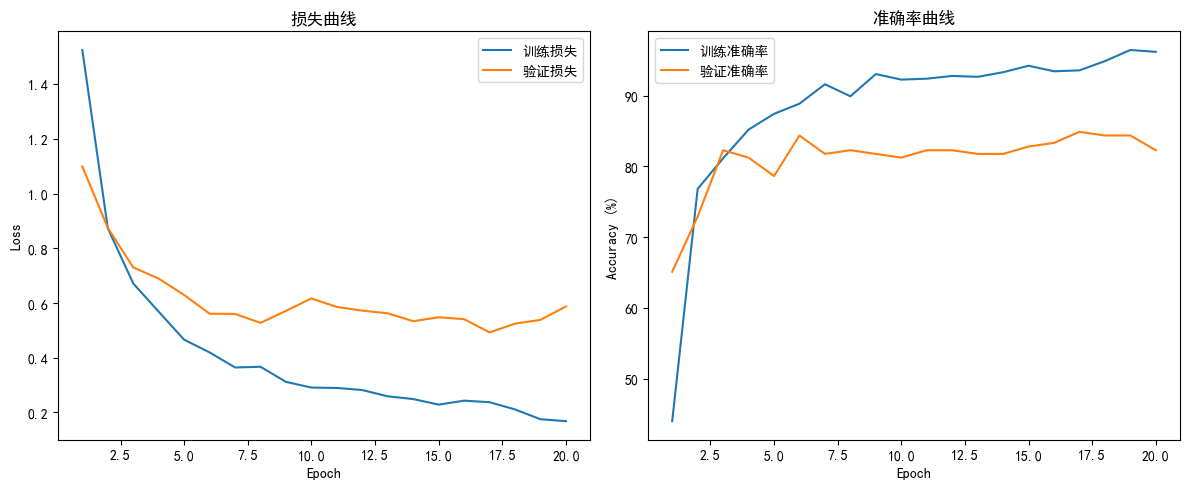


=== 步骤5: 可视化训练过程完成 ===


In [7]:
# 步骤5: 可视化训练过程
print("\n=== 步骤5: 可视化训练过程 ===")
print("绘制训练和验证的损失及准确率曲线。")
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans', 'Arial Unicode MS', 'WenQuanYi Zen Hei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
# 绘制损失曲线
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, label='训练损失')
plt.plot(range(1, epochs+1), val_losses, label='验证损失')
plt.title('损失曲线')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# 绘制准确率曲线
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), train_accuracies, label='训练准确率')
plt.plot(range(1, epochs+1), val_accuracies, label='验证准确率')
plt.title('准确率曲线')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

print("\n=== 步骤5: 可视化训练过程完成 ===")


In [ ]:
# 步骤6: 保存模型
print("\n=== 步骤6: 保存模型 ===")
print("保存训练好的模型。")

# 保存模型
model_save_path = f'baseline_{model_name}_improved.pth'
print(f"\n保存模型到: {model_save_path}")

torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'val_accuracy': val_accuracy,
    'classes': dataset.classes
}, model_save_path)

print(f"模型保存成功!")
print(f"模型文件大小: {os.path.getsize(model_save_path) / 1024 / 1024:.2f} MB")

print("\n=== 步骤6: 保存模型完成 ===")


In [ ]:
# 步骤7: 模型评估
print("\n=== 步骤7: 模型评估 ===")
print("评估模型在验证集上的表现。")

# 评估模型
model.eval()
correct = 0
total = 0
class_correct = {cls: 0 for cls in dataset.classes}
class_total = {cls: 0 for cls in dataset.classes}

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # 统计每个类别的准确率
        for i in range(len(labels)):
            label = labels[i].item()
            class_total[dataset.classes[label]] += 1
            if predicted[i] == label:
                class_correct[dataset.classes[label]] += 1

print(f"验证集准确率: {100 * correct / total:.2f}%")

print("\n每个类别的准确率:")
for cls in dataset.classes:
    if class_total[cls] > 0:
        print(f"{cls}: {100 * class_correct[cls] / class_total[cls]:.2f}% ({class_correct[cls]}/{class_total[cls]})")
    else:
        print(f"{cls}: N/A (0/0)")

print("\n=== 步骤7: 模型评估完成 ===")

# 步骤8: 预测示例
print("\n=== 步骤8: 预测示例 ===")
print("使用训练好的模型进行预测示例。")

# 预测函数
def predict_image(image_path, model, transform):
    """使用模型预测图片"""
    try:
        # 加载图片
        image = Image.open(image_path).convert('RGB')
        
        # 预处理
        img_tensor = transform(image).unsqueeze(0).to(device)
        
        # 预测
        model.eval()
        with torch.no_grad():
            outputs = model(img_tensor)
            _, predicted = torch.max(outputs, 1)
            confidence = torch.nn.functional.softmax(outputs, dim=1)[0][predicted.item()].item()
        
        # 获取类别名称
        predicted_class = dataset.classes[predicted.item()]
        
        return predicted_class, confidence
    except Exception as e:
        return str(e), 0.0

# 预测示例
sample_images = [
    'minet/biotite/0001.jpg',
    'minet/bornite/0001.jpg',
    'minet/chrysocolla/0001.jpg',
    'minet/malachite/0001.jpg',
    'minet/muscovite/0001.jpg',
    'minet/pyrite/0001.jpg',
    'minet/quartz/0001.jpg'
]

print("预测示例:")
for image_path in sample_images:
    if os.path.exists(image_path):
        predicted_class, confidence = predict_image(image_path, model, transform_val)
        print(f"图片: {image_path.split('/')[-2]}/{image_path.split('/')[-1]}")
        print(f"预测结果: {predicted_class}")
        print(f"置信度: {confidence:.2f}")
        print()
    else:
        print(f"图片不存在: {image_path}")
        print()

print("\n=== 步骤8: 预测示例完成 ===")
